In [2]:
import pandas as pd
import re
import numpy as np
import os

In [3]:
df = pd.read_csv('K:\\autonation\\AD HOC\\Rini\\TimeDecay\\EM_responders.csv')

In [4]:
df.head()

,CURR_AG_IND_ID,COMMUNICATION_ID,drop_date,first_purch_dt,no_of_touches,days_to_resp,wt_resp
0,1000000000207,EPSI_204806661-1596602963,29JAN2022,03FEB2022,2,5,0.609507
1,1000000000207,EPSI_205012174-1598198852,02FEB2022,03FEB2022,2,1,0.905724
2,1000000000207,EPSI_207475501-1634104718,06APR2022,21APR2022,1,15,0.226431
3,1000000000207,EPSI_209870347-1655893531,01JUN2022,02JUN2022,3,1,0.905724
4,1000000000207,EPSI_209615884-1655436927,25MAY2022,02JUN2022,3,8,0.452862


In [94]:
df.dtypes

CURR_AG_IND_ID        int64
COMMUNICATION_ID     object
drop_date            object
first_purch_dt       object
no_of_touches         int64
days_to_resp          int64
wt_resp             float64
dtype: object

In [27]:
df['Unique_veh_purch_id'] = df['CURR_AG_IND_ID'].astype(str).str.cat(df['first_purch_dt'])
df.head()

,CURR_AG_IND_ID,COMMUNICATION_ID,drop_date,first_purch_dt,no_of_touches,days_to_resp,wt_resp,Unique_veh_purch_id
0,1000000000207,EPSI_204806661-1596602963,29JAN2022,03FEB2022,2,5,0.609507,100000000020703FEB2022
1,1000000000207,EPSI_205012174-1598198852,02FEB2022,03FEB2022,2,1,0.905724,100000000020703FEB2022
2,1000000000207,EPSI_207475501-1634104718,06APR2022,21APR2022,1,15,0.226431,100000000020721APR2022
3,1000000000207,EPSI_209870347-1655893531,01JUN2022,02JUN2022,3,1,0.905724,100000000020702JUN2022
4,1000000000207,EPSI_209615884-1655436927,25MAY2022,02JUN2022,3,8,0.452862,100000000020702JUN2022


In [6]:
df['days_to_resp'].value_counts()

1      11444
2      11254
7      10585
8      10541
15      9974
       ...  
119        1
122        1
140        1
114        1
109        1
Name: days_to_resp, Length: 167, dtype: int64

In [28]:
# only keeping records for people who responded within 30 days
df_sub = df[df['days_to_resp']<=30]
print(df_sub.shape)
# df_sub['no_of_touches'].value_counts()

(277555, 8)


In [ ]:
df['days_to_resp'].value_counts()

In [29]:
df_resp = df_sub.groupby('days_to_resp').aggregate({'Unique_veh_purch_id':'nunique','wt_resp':'mean'}).reset_index()
df_resp.rename(columns = {'Unique_veh_purch_id':'no_of_purchasers'}, inplace = True)
df_resp['wt*purchasers'] = df_resp['no_of_purchasers']*df_resp['wt_resp']
df_resp.head(20)

,days_to_resp,no_of_purchasers,wt_resp,wt*purchasers
0,1,10857,0.905724,9833.441823
1,2,10707,0.820335,8783.330657
2,3,8798,0.742997,6536.888878
3,4,8993,0.672950,6051.840216
4,5,8511,0.609507,5187.512605
5,6,9329,0.552045,5150.025536
6,7,10173,0.500000,5086.500000
7,8,10131,0.452862,4587.943221
8,9,9526,0.410168,3907.257301
9,10,8417,0.371499,3126.903483


In [140]:
df_resp.to_csv("K:\\autonation\\AD HOC\\Rini\\TimeDecay\\EM_Resp_Aggregated_data.csv", index = False)

In [30]:
xweight = df_resp['wt*purchasers'].mean()
xweight

2823.8458849962467

In [31]:
import matplotlib.pyplot as plt
%matplotlib inline

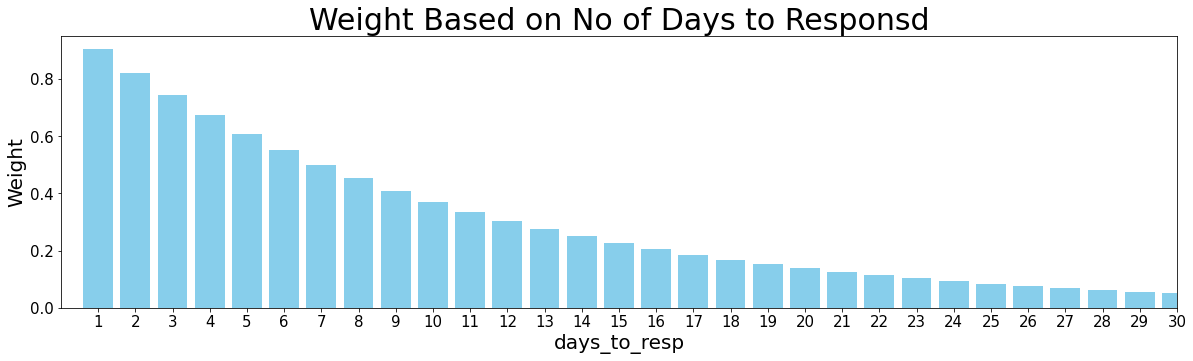

In [35]:
fig = plt.figure(figsize = (20, 5))
 
# creating the bar plot
plt.bar(df_resp['days_to_resp'], df_resp['wt_resp'], color ='skyblue',
        width = 0.8)
plt.xlim([0, 30])
# plt.axvline(x=xweight, color='r')
# plt.axhline(y = xweight, color ="r", linestyle ="--")
plt.xlabel("days_to_resp", fontsize=20)
plt.xticks(df_resp['days_to_resp'], fontsize=15)
plt.yticks(fontsize=15)

plt.ylabel("Weight", fontsize=20)
plt.title("Weight Based on No of Days to Responsd", fontsize=30)
plt.savefig('K:\\autonation\\AD HOC\\Rini\TimeDecay\\Charts\\Weights.jpg')

plt.show()

In [ ]:
fig = plt.figure(figsize = (20, 5))
 
# creating the bar plot
plt.bar(df_resp['days_to_resp'], df_resp['wt*purchasers'], color ='skyblue',
        width = 0.8)
plt.xlim([0, 30])
# plt.axvline(x=xweight, color='r')
# plt.axhline(y = xweight, color ="r", linestyle ="--")
plt.xlabel("days_to_resp", fontsize=20)
plt.xticks(df_resp['days_to_resp'], fontsize=15)
plt.yticks(fontsize=15)

plt.ylabel("Weight*No_of_purchasers", fontsize=20)
plt.title("Decay Curve for all Touches", fontsize=30)
plt.savefig('K:\\autonation\\AD HOC\\Rini\TimeDecay\\Charts\\EM_resp_All_touches.jpg')

plt.show()

In [ ]:
# For frequency, plots for each touch

In [164]:
df_touch = df_sub[df_sub['no_of_touches'] == 15]
df_touch.shape

(75, 8)

In [113]:
df_touch = df_sub[(df_sub['no_of_touches'] > 10) & (df_sub['no_of_touches'] < 16)]
df_touch.shape
# df_touch.head(20)

(488, 8)

In [116]:
df_touch['no_of_touches'].value_counts()

1    73295
Name: no_of_touches, dtype: int64

In [ ]:
df_touch_resp = df_touch.groupby('days_to_resp').aggregate({'Unique_veh_purch_id':'nunique','wt_resp':'mean'}).reset_index()
df_touch_resp.rename(columns = {'Unique_veh_purch_id':'no_of_purchasers'}, inplace = True)
df_touch_resp['wt*purchasers'] = df_touch_resp['no_of_purchasers']*df_touch_resp['wt_resp']
df_touch_resp.head(20)

In [166]:
xweight2 = df_touch_resp['wt*purchasers'].mean()
xweight2

0.5515527132684209

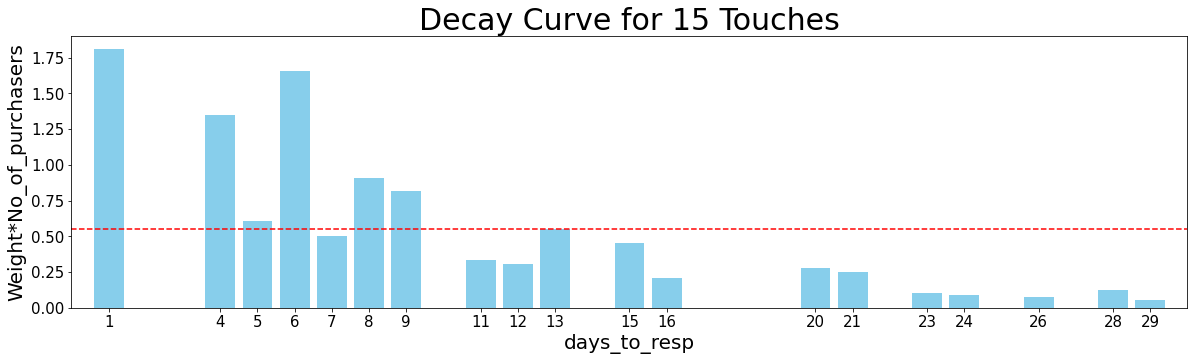

In [167]:
fig = plt.figure(figsize = (20, 5))
 
# creating the bar plot
plt.bar(df_touch_resp['days_to_resp'], df_touch_resp['wt*purchasers'], color ='skyblue',
        width = 0.8)
plt.xlim([0, 30])
# plt.axvline(x=xweight, color='r')
plt.axhline(y = xweight2, color ="r", linestyle ="--")
plt.xlabel("days_to_resp", fontsize=20)
plt.xticks(df_touch_resp['days_to_resp'], fontsize=15)
plt.yticks(fontsize=15)

plt.ylabel("Weight*No_of_purchasers", fontsize=20)
plt.title("Decay Curve for 15 Touches", fontsize=30)
plt.savefig('K:\\autonation\\AD HOC\\Rini\TimeDecay\\Charts\\EM_resp_15Touch.jpg')

plt.show()

In [172]:
## Breaking it out by Touc

In [16]:
df_sub = df[df['days_to_resp']<=30]
df_sub2 = df_sub[df_sub['no_of_touches']<=15]

In [17]:
df_touch_wt = df_sub2.groupby('no_of_touches').aggregate({'wt_resp':'mean'}).reset_index()
df_touch_wt.head(20)

,no_of_touches,wt_resp
0,1,0.352691
1,2,0.311747
2,3,0.302363
3,4,0.301943
4,5,0.299979
5,6,0.296758
6,7,0.300734
7,8,0.318032
8,9,0.317082
9,10,0.316151


In [20]:
df_touch_wt2 = df_sub2.groupby('no_of_touches').aggregate({'Unique_veh_purch_id':'nunique','wt_resp':'mean'}).reset_index()
df_touch_wt2.rename(columns = {'Unique_veh_purch_id':'no_of_purchasers'}, inplace = True)
df_touch_wt2['wt*purchasers'] = df_touch_wt2['no_of_purchasers']*df_touch_wt2['wt_resp']
df_touch_wt2.head(20)

,no_of_touches,no_of_purchasers,wt_resp,wt*purchasers
0,1,73295,0.352691,25850.469115
1,2,34807,0.311747,10850.977356
2,3,19396,0.302363,5864.628090
3,4,9940,0.301943,3001.316800
4,5,4260,0.299979,1277.909870
5,6,1558,0.296758,462.348195
6,7,529,0.300734,159.088120
7,8,218,0.318032,69.330966
8,9,81,0.317082,25.683629
9,10,38,0.316151,12.013750


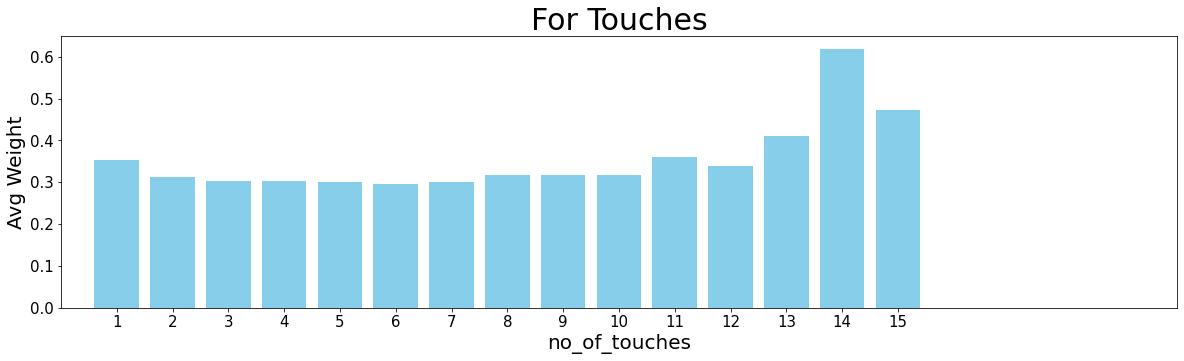

In [25]:
fig = plt.figure(figsize = (20, 5))
 
# creating the bar plot
plt.bar(df_touch_wt['no_of_touches'], df_touch_wt['wt_resp'], color ='skyblue',
        width = 0.8)
plt.xlim([0, 20])
# plt.axvline(x=xweight, color='r')
# plt.axhline(y = xweight2, color ="r", linestyle ="--")
plt.xlabel("no_of_touches", fontsize=20)
plt.xticks(df_touch_wt['no_of_touches'], fontsize=15)
plt.yticks(fontsize=15)

plt.ylabel("Avg Weight", fontsize=20)
plt.title("For Touches", fontsize=30)
plt.savefig('K:\\autonation\\AD HOC\\Rini\TimeDecay\\Charts\\Touch_wts.jpg')

plt.show()

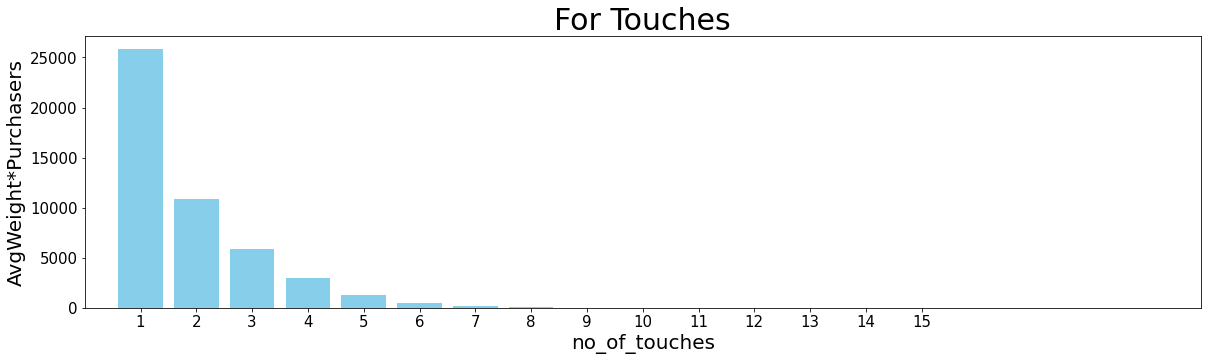

In [26]:
fig = plt.figure(figsize = (20, 5))
 
# creating the bar plot
plt.bar(df_touch_wt2['no_of_touches'], df_touch_wt2['wt*purchasers'], color ='skyblue',
        width = 0.8)
plt.xlim([0, 20])
# plt.axvline(x=xweight, color='r')
# plt.axhline(y = xweight2, color ="r", linestyle ="--")
plt.xlabel("no_of_touches", fontsize=20)
plt.xticks(df_touch_wt2['no_of_touches'], fontsize=15)
plt.yticks(fontsize=15)

plt.ylabel("AvgWeight*Purchasers", fontsize=20)
plt.title("For Touches", fontsize=30)
plt.savefig('K:\\autonation\\AD HOC\\Rini\TimeDecay\\Charts\\Touch_wts_responders.jpg')

plt.show()